<a href="https://colab.research.google.com/github/nicoholth/INFO284Semesterassignment/blob/Heine/Task1_Sentiment.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Task 1 - Sentiment Analysis

## 1. Introduction

## 2. Exploratory Data Analysis (EDA)

In [5]:
!git clone https://github.com/nicoholth/INFO284Semesterassignment.git

Cloning into 'INFO284Semesterassignment'...
remote: Enumerating objects: 1181, done.
remote: Counting objects: 100% (25/25), done.
remote: Compressing objects: 100% (19/19), done.
remote: Total 1181 (delta 15), reused 9 (delta 5), pack-reused 1156 (from 1)
Receiving objects: 100% (1181/1181), 1.62 GiB | 44.35 MiB/s, done.
Resolving deltas: 100% (99/99), done.
Updating files: 100% (988/988), done.


In [6]:
import os
os.chdir("INFO284Semesterassignment")

In [7]:
!ls data

Art_shuffled  Own_images  reviews.csv


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set(style="whitegrid")

In this segment we imported several Python libraries. Firstly we imported Pandas which is used for working with data in a table format. This is especially important for us considering our data was presented in a CSV file. Secondly we imported NumPy, which is a library used for numerical operations. Lastly, we imported Matplotlib and Seaborn, which we used to create graphs and charts to visualize our findings.

In [ ]:
df = pd.read_csv("data/reviews.csv")

df.head()

,review_id,rating,review_text,review_date,helpful
0,981e465b-d3ba-4632-9c60-25051efac38a,5,It's good,11/22/2025 1:19,0
1,964d3555-9429-4c20-8127-ce3c71ce9273,5,WhatsApp not working well always shows offline...,11/24/2025 20:03,0
2,6c28859f-1554-4ca1-9aa8-9d66f204be0a,5,"Oppo not corresponding, share with me the offi...",11/25/2025 6:26,0
3,a7efafc3-5871-4020-a398-9cc12cb4072a,5,"Excellent app, great communication super conne...",11/25/2025 18:09,0
4,de142b31-a5ad-446f-b7c8-51b264728478,4,simply the ɓest for chat and calls.i love it,11/24/2025 1:10,1


We used the "pd.read_csv()" pandas functionto read data from our CSV file and then used "df.head()" to display the first few rows of the dataset. This was to make sure our data was imported correctly.

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6210 entries, 0 to 6209
Data columns (total 5 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   review_id    6210 non-null   object
 1   rating       6210 non-null   int64 
 2   review_text  6210 non-null   object
 3   review_date  6210 non-null   object
 4   helpful      6210 non-null   int64 
dtypes: int64(2), object(3)
memory usage: 242.7+ KB


From this we can read that our DataFrame contains 6210 rows, 5 columns with a row index ranging from 0 to 6209. Every column has "6210 non-null" whch means there are no missing values in the dataset. This is good because less cleaning is needed.

In [ ]:
df.describe()

,rating,helpful
count,6210.000000,6210.000000
mean,3.490016,43.463607
std,1.703590,3161.807086
min,1.000000,0.000000
25%,1.000000,0.000000
50%,4.000000,0.000000
75%,5.000000,0.000000
max,5.000000,248962.000000


Our dataset shows that the ratings appear polarixed, with many very low ratings and many very high ratings. This is not uncommon when working with reviews where users only rate when very happy or very unhappy.

In [ ]:
df["rating"].value_counts()

,count
rating,
5,3021
1,1582
4,632
3,508
2,467


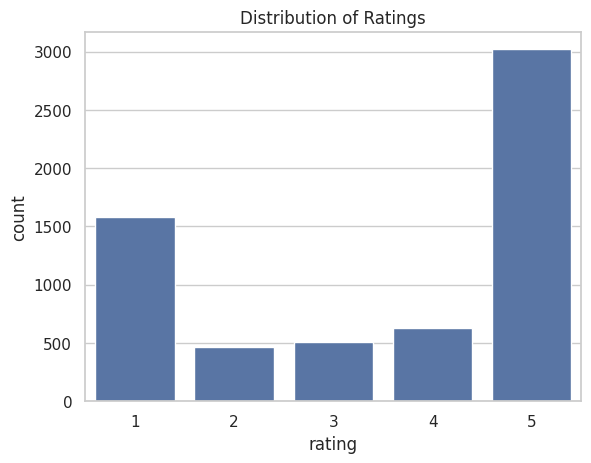

In [ ]:
sns.countplot(x="rating", data=df)
plt.title("Distribution of Ratings")
plt.show()

The dataset contains 6210 reviews. There are 1582 1-star reviews, 467 2-star reviews, 508 3-star reviews, 632 4-star reviews and 3021 5-star reviews. This shows a bit of imbalanced distribution. The imbalance may have an effect on how the model preforms, especially if accuracy score is the only metric considered.

In [ ]:
df["review_length"] = df["review_text"].str.len()

df["review_length"].describe()

,review_length
count,6210.000000
mean,93.598390
std,130.661464
min,3.000000
25%,22.000000
50%,44.000000
75%,100.000000
max,1260.000000


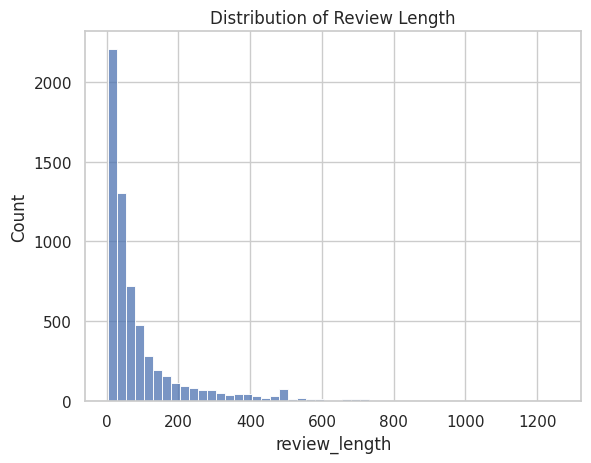

In [ ]:
sns.histplot(df["review_length"], bins=50)
plt.title("Distribution of Review Length")
plt.show()

The average length of the reviews are 93 characters. The standar deviation is aproximately 131. This idicates that there is a large variation in length. Many are short, and some are very long. This variability may influence preproceccing decisions.

In [ ]:
df["review_text"].isnull().sum()

np.int64(0)

In [ ]:
(df["review_text"].str.strip() == "").sum()

np.int64(0)

None of the reviews are empty, and it's not nessasary to remove any rows.

## 3. Preprocessing

In this step the text is cleaned before feature extaction.

In [ ]:
df["review_text"] = df["review_text"].str.lower()

In [ ]:
import re

df["review_text"] = df["review_text"].apply(lambda x: re.sub(r"[^\w\s]", "", x))

In [ ]:
import nltk
nltk.download('stopwords')

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


True

In [ ]:
from nltk.corpus import stopwords

stop_words = set(stopwords.words("english"))

In [ ]:
df["review_text"] = df["review_text"].apply(
    lambda x: " ".join([word for word in x.split() if word not in stop_words])
)

In [ ]:
lengths = df["review_text"].apply(lambda x: len(x.split()))

lower = lengths.quantile(0.01)
upper = lengths.quantile(0.99)

df = df[(lengths > lower) & (lengths < upper)]

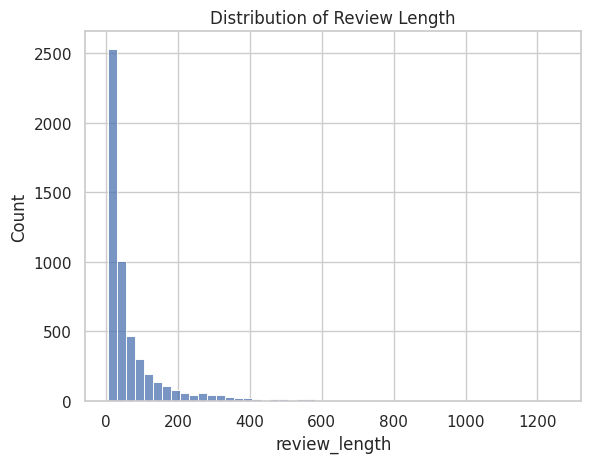

In [ ]:
df["review_length"] = df["review_text"].apply(len)
sns.histplot(df["review_length"], bins=50)
plt.title("Distribution of Review Length")
plt.show()

## 4. Feature Engineering

In [ ]:
from sklearn.feature_extraction.text import TfidfVectorizer

In [ ]:
vectorizer = TfidfVectorizer(max_features=5000, ngram_range=(1,2))

In [ ]:
X = vectorizer.fit_transform(df["review_text"])
y = df["rating"]

In [ ]:
X.shape

(5264, 5000)

TF-IDF vectorization converts the review texts into numerical features. Each review is represented as a vector where the values reflect the importance of words in the dataset. This allows machine learning models to process textual data.

## 5. Models

In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [ ]:
X_train.shape

(4211, 5000)

The dataset is split into training and test sets in order to evaluate model performance on unseen data.

### 5.1 Model 1 - Logistic Regression (Classification)

In [ ]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(max_iter=1000)

model.fit(X_train, y_train)

LogisticRegression(max_iter=1000)

In [ ]:
predictions = model.predict(X_test)

In [ ]:
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(y_test, predictions)
accuracy

0.6144349477682811

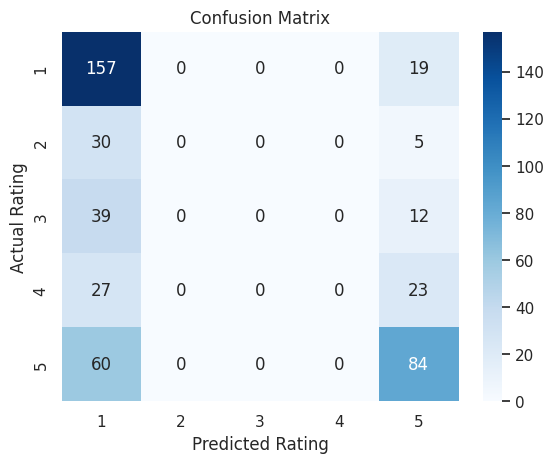

In [ ]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, predictions)

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=[1,2,3,4,5],
    yticklabels=[1,2,3,4,5]
)

plt.xlabel("Predicted Rating")
plt.ylabel("Actual Rating")
plt.title("Confusion Matrix")
plt.show()

The model preforms well for the most frequent classes, in this case ratings 1 and 5, but struggles to predict the middle ratings. This is most likley due to imbalance in the dataset.

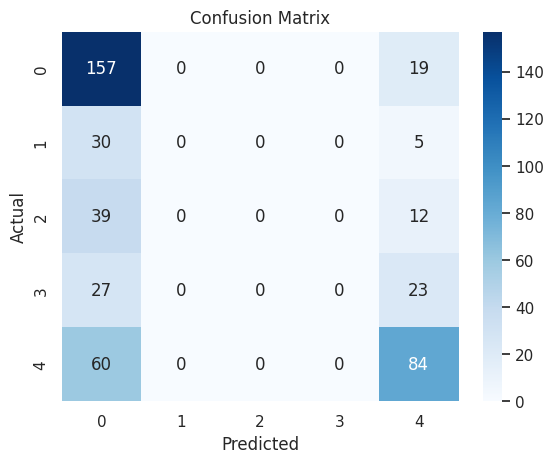

In [ ]:
from sklearn.metrics import confusion_matrix
import seaborn as sns

cm = confusion_matrix(y_test, predictions)

sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

### 5.2 Model 2 Random Forest Classifier

In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report

Importerer Random Forest Classifier modellen fra sckit-learn.

In [ ]:
rf = RandomForestClassifier(n_estimators=100,random_state=42,n_jobs=-1)


Oppretter modellen med antall trær i skogen lik 100.

In [ ]:
rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)

print(classification_report(y_test, y_pred_rf))

              precision    recall  f1-score   support

           1       0.53      0.60      0.56       321
           2       0.33      0.01      0.02        96
           3       0.17      0.02      0.04        99
           4       0.24      0.03      0.05       130
           5       0.61      0.87      0.72       596

    accuracy                           0.58      1242
   macro avg       0.38      0.31      0.28      1242
weighted avg       0.49      0.58      0.50      1242



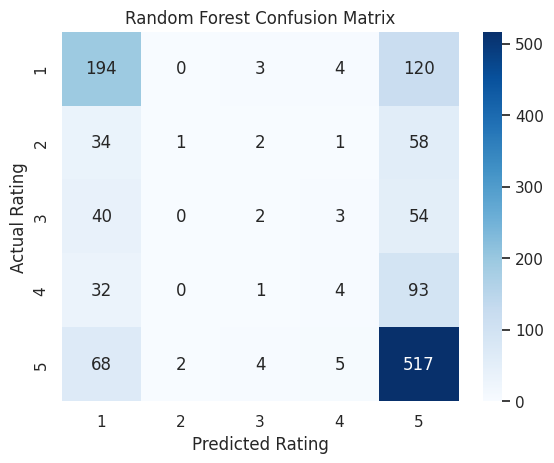

In [ ]:
from sklearn.metrics import confusion_matrix
cm = confusion_matrix(y_test,y_pred_rf)

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=[1,2,3,4,5],
    yticklabels=[1,2,3,4,5])

plt.xlabel("Predicted Rating")
plt.ylabel("Actual Rating")
plt.title("Random Forest Confusion Matrix")
plt.show()

### 5.3 Model 3 Linear Regression (Regression)

In [ ]:
from sklearn.linear_model import LinearRegression

In [ ]:
lin_model = LinearRegression()

In [ ]:
lin_model.fit(X_train, y_train)

LinearRegression()

In [ ]:
lin_predictions = lin_model.predict(X_test)

In [ ]:
import numpy as np

lin_predictions_rounded = np.round(lin_predictions)
lin_predictions_rounded = np.clip(lin_predictions_rounded, 1, 5)

In [ ]:
lin_accuracy = accuracy_score(y_test, lin_predictions_rounded)
lin_accuracy

0.40096618357487923

In [ ]:
from sklearn.metrics import mean_squared_error, mean_absolute_error

mse = mean_squared_error(y_test, lin_predictions)
mae = mean_absolute_error(y_test, lin_predictions)

mse, mae

(103.22262295277774, 5.761288422878234)

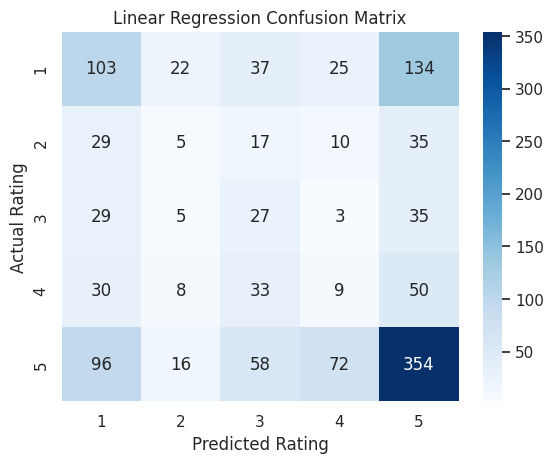

In [ ]:
cm = confusion_matrix(y_test, lin_predictions_rounded)

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=[1,2,3,4,5],
    yticklabels=[1,2,3,4,5]
)

plt.xlabel("Predicted Rating")
plt.ylabel("Actual Rating")
plt.title("Linear Regression Confusion Matrix")
plt.show()

### 5.4 Model 4 LSTM Nerual Network

First we need to create Tokenization as TF-IDF can not be used directly with LSTM. LSTM needs Sequential ordering of the words not, bag-of-words.

In [ ]:
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences

In [ ]:
max_words = 10000
max_len = 300

In [ ]:
tokenizer = Tokenizer(num_words=max_words)
tokenizer.fit_on_texts(df["review_text"])

In [ ]:
sequences = tokenizer.texts_to_sequences(df["review_text"])
X_seq = pad_sequences(sequences, maxlen=max_len)

Create categorical classifications for the ratings 1-5.

In [ ]:

from tensorflow.keras.utils import to_categorical

In [ ]:
y = to_categorical(df["rating"] - 1)  # gjør om 1–5 → 0–4

Create train/test split.

In [ ]:
from sklearn.model_selection import train_test_split

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X_seq, y, test_size=0.2, random_state=42
)

In [ ]:


from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM, Dense, Dropout

model = Sequential()

In [ ]:
# Embedding layer
model.add(Embedding(input_dim=max_words, output_dim=128, input_length=max_len))

# LSTM layer
model.add(LSTM(64, return_sequences=False))

# Regularization
model.add(Dropout(0.5))

# Output layer (5 klasser)
model.add(Dense(5, activation="softmax"))

model.compile(
    loss="categorical_crossentropy",
    optimizer="adam",
    metrics=["accuracy"]
)

model.summary()




history = model.fit(
    X_train,
    y_train,
    epochs=5,
    batch_size=32,
    validation_split=0.2
)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

Epoch 1/5
125/125 ━━━━━━━━━━━━━━━━━━━━ 22s 126ms/step - accuracy: 0.5317 - loss: 1.2769 - val_accuracy: 0.5473 - val_loss: 1.2521
Epoch 2/5
125/125 ━━━━━━━━━━━━━━━━━━━━ 14s 115ms/step - accuracy: 0.6246 - loss: 1.0828 - val_accuracy: 0.5594 - val_loss: 1.2074
Epoch 3/5
125/125 ━━━━━━━━━━━━━━━━━━━━ 10s 83ms/step - accuracy: 0.6963 - loss: 0.9036 - val_accuracy: 0.5644 - val_loss: 1.2898
Epoch 4/5
125/125 ━━━━━━━━━━━━━━━━━━━━ 10s 79ms/step - accuracy: 0.7486 - loss: 0.7504 - val_accuracy: 0.5463 - val_loss: 1.3859
Epoch 5/5
125/125 ━━━━━━━━━━━━━━━━━━━━ 15s 120ms/step - accuracy: 0.8037 - loss: 0.6295 - val_accuracy: 0.5292 - val_loss: 1.4617


Evaluation

In [ ]:
loss, accuracy = model.evaluate(X_test, y_test)
print("Test accuracy:", accuracy)

39/39 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step - accuracy: 0.5523 - loss: 1.3564
Test accuracy: 0.5523349642753601


## 6. Evaluation

## 7. Discussion

## 8. Conclusion

# Task 2

## Task 2 a

In [64]:
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator

img_size = (224, 224)
batch_size = 32

datagen = ImageDataGenerator(
    rescale=1./255,
    validation_split=0.2
)

train_data = datagen.flow_from_directory(
    "data/Art_shuffled",
    target_size=img_size,
    batch_size=batch_size,
    class_mode="binary",
    subset="training"
)

val_data = datagen.flow_from_directory(
    "data/Art_shuffled",
    target_size=img_size,
    batch_size=batch_size,
    class_mode="binary",
    subset="validation"
)

Found 752 images belonging to 2 classes.
Found 186 images belonging to 2 classes.


Stronger agumentation

In [65]:
datagen = ImageDataGenerator(
    rescale=1./255,
    validation_split=0.2,
    rotation_range=15,
    width_shift_range=0.05,
    height_shift_range=0.05,
    zoom_range=0.1,
    horizontal_flip=True
)

MobileNetV2 better confidence but low accuracy.

In [66]:
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras import layers, models

base_model = MobileNetV2(
    weights="imagenet",
    include_top=False,
    input_shape=(224, 224, 3)
)

base_model.trainable = False

EfficientNetB0 better accuracy but lower confidence. With fine-tune to un-freeze top layers

In [55]:
from tensorflow.keras.applications import EfficientNetB0
from tensorflow.keras import layers, models

base_model = EfficientNetB0(weights="imagenet", include_top=False, input_shape=(224,224,3))
base_model.trainable = False  # start frozen

x = layers.GlobalAveragePooling2D()(base_model.output)
x = layers.BatchNormalization()(x)
x = layers.Dense(128, activation="relu")(x)
x = layers.Dropout(0.5)(x)
output = layers.Dense(1, activation="sigmoid")(x)

model = models.Model(inputs=base_model.input, outputs=output)

model.compile(optimizer="adam", loss="binary_crossentropy", metrics=["accuracy"])

for layer in base_model.layers[-30:]:
    layer.trainable = True

model.compile(optimizer=tf.keras.optimizers.Adam(1e-5),
              loss="binary_crossentropy",
              metrics=["accuracy"])

In [67]:
x = base_model.output
x = layers.GlobalAveragePooling2D()(x)
x = layers.Dense(128, activation="relu")(x)
x = layers.Dropout(0.5)(x)
output = layers.Dense(1, activation="sigmoid")(x)

model = models.Model(inputs=base_model.input, outputs=output)

In [68]:
model.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

In [69]:
history = model.fit(
    train_data,
    validation_data=val_data,
    epochs=5
)

Epoch 1/5
24/24 ━━━━━━━━━━━━━━━━━━━━ 97s 4s/step - accuracy: 0.6090 - loss: 0.7241 - val_accuracy: 0.6882 - val_loss: 0.5460
Epoch 2/5
24/24 ━━━━━━━━━━━━━━━━━━━━ 81s 3s/step - accuracy: 0.7766 - loss: 0.4670 - val_accuracy: 0.7419 - val_loss: 0.5022
Epoch 3/5
24/24 ━━━━━━━━━━━━━━━━━━━━ 81s 3s/step - accuracy: 0.8404 - loss: 0.3837 - val_accuracy: 0.7796 - val_loss: 0.4963
Epoch 4/5
24/24 ━━━━━━━━━━━━━━━━━━━━ 80s 3s/step - accuracy: 0.8830 - loss: 0.3206 - val_accuracy: 0.7796 - val_loss: 0.4924
Epoch 5/5
24/24 ━━━━━━━━━━━━━━━━━━━━ 86s 4s/step - accuracy: 0.8936 - loss: 0.2749 - val_accuracy: 0.7688 - val_loss: 0.5038


In [70]:
loss, accuracy = model.evaluate(val_data)
print("Accuracy:", accuracy)

6/6 ━━━━━━━━━━━━━━━━━━━━ 18s 3s/step - accuracy: 0.7688 - loss: 0.5038
Accuracy: 0.7688171863555908


## Task 2 b

In [71]:
def predict_image(path):
    img = image.load_img(path, target_size=(224,224))
    img_array = image.img_to_array(img) / 255.0
    img_array = np.expand_dims(img_array, axis=0)

    prediction = model.predict(img_array)[0][0]

    label = ""
    confidence = 0.0

    if prediction > 0.5:
        label = "AI generated"
        confidence = prediction
    else:
        label = "Human created"
        confidence = 1 - prediction

    plt.imshow(img)
    plt.title(f"{label} ({confidence:.2f})")
    plt.axis("off")
    plt.show()

    print(f"AI probability: {prediction:.2f}")
    print(f"Human probability: {1 - prediction:.2f}")

Human created
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step


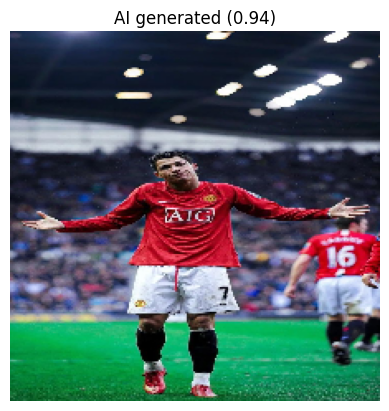

AI probability: 0.94
Human probability: 0.06


In [72]:
print("Human created")
predict_image("data/Own_images/૮ •〃• ა_ ★.jpg")

Human created
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 130ms/step


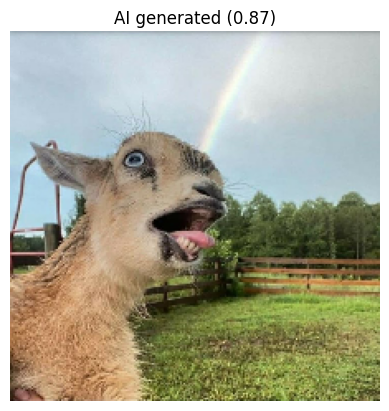

AI probability: 0.87
Human probability: 0.13


In [73]:
print("Human created")
predict_image("data/Own_images/731905376985592520.jpg")

AI created
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 68ms/step


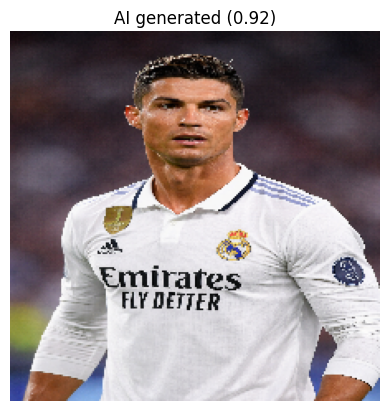

AI probability: 0.92
Human probability: 0.08


In [74]:
print("AI created")
predict_image("data/Own_images/ChatGPT Image 20. apr. 2026, 12_54_49.png")

AI created
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 70ms/step


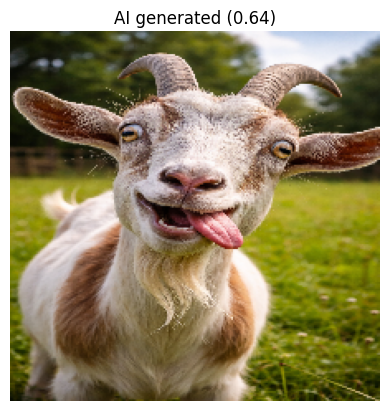

AI probability: 0.64
Human probability: 0.36


In [75]:
print("AI created")
predict_image("data/Own_images/ChatGPT Image 20. apr. 2026, 12_55_44.png")

AI created
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 70ms/step


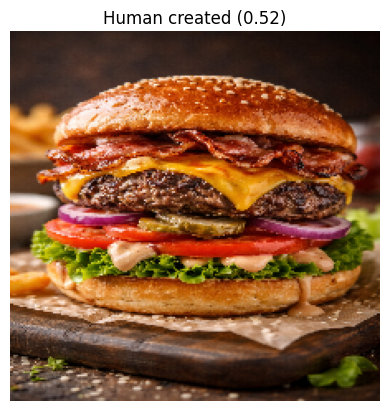

AI probability: 0.48
Human probability: 0.52


In [76]:
print("AI created")
predict_image("data/Own_images/ChatGPT Image 20. apr. 2026, 12_57_34.png")